# FD001 interview walkthrough

Executed artifact inspection from the recorded pipeline. Re-run the pipeline from the repository root before refreshing these cells. No fitting occurs inside the notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'reports').exists() else Path.cwd().parent
R = ROOT / 'reports'
print(json.loads((R / 'run_manifest.json').read_text())['completed_utc'])

2026-09-07T15:27:40.943096+00:00


# Data and EDA reasoning

The official NASA archive is retained by reference and identity hashes. Parsing rejects wrong column counts, missing/non-finite values, duplicate engine/cycle pairs and noncontiguous cycles. Every raw column is documented in data/column_dictionary.csv. Sensor symbols and units follow Table 2 in the bundled NASA modeling paper; operational setting names/units remain unspecified where the numbered text schema does not identify their order. HPC/LPC mean high/low pressure compressor; HPT/LPT mean high/low pressure turbine. The source labels PCNfR_dmd in rpm; preserve that attribution rather than silently interpreting the stored scale.

Partition training engines before learning any sensor policy. Lifetimes for the supplied train file are descriptive; sensor decisions, slopes and starting-condition statistics use only the fitting partition. See engine_lifetimes.csv, engine_sensor_analysis.csv, operating_settings.csv and sensor_analysis.csv.

Each sensor's pooled variance and Pearson correlations with cycle, raw RUL and clipped RUL are reported. Pooled correlations can reflect engine offsets, so retention uses median within-engine absolute Spearman correlation and linear-fit R2. Monotonicity is the absolute mean sign of first differences after a causal rolling mean. Trend strength is within-engine linear R2. Noise proxy is std(first difference)/sqrt(2*variance); it includes some degradation signal and is not a measured sensor-noise calibration.

The recorded selection rules are {'minimum_unique': 3, 'minimum_median_abs_spearman': 0.3, 'minimum_trend_r2': 0.1}. These are project analysis rules, not NASA limits or optimized physical constants. Remove low-cardinality channels, Investigate weak trends, Keep supported trends. Normalize is recorded as a separate preprocessing action on every Keep sensor: physical scales should not determine PCA loadings or LSTM optimization. No sensor must receive each verdict just to fill the categories. Starting-condition variation is the between-engine standard deviation of the first 20 cycle means. Degradation rates are descriptive whole-life slopes, not constant-rate physical models.

| sensor | classification | preprocessing | reason |
| --- | --- | --- | --- |
| sensor_1 | Remove | nan | Only 1 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_2 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.670, trend R2=0.468; retain and standardize on training engines. |
| sensor_3 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.648, trend R2=0.441; retain and standardize on training engines. |
| sensor_4 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.787, trend R2=0.625; retain and standardize on training engines. |
| sensor_5 | Remove | nan | Only 1 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_6 | Remove | nan | Only 2 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_7 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.776, trend R2=0.614; retain and standardize on training engines. |
| sensor_8 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.769, trend R2=0.605; retain and standardize on training engines. |
| sensor_9 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.739, trend R2=0.557; retain and standardize on training engines. |
| sensor_10 | Remove | nan | Only 1 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_11 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.820, trend R2=0.667; retain and standardize on training engines. |
| sensor_12 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.809, trend R2=0.660; retain and standardize on training engines. |
| sensor_13 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.762, trend R2=0.599; retain and standardize on training engines. |
| sensor_14 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.776, trend R2=0.615; retain and standardize on training engines. |
| sensor_15 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.722, trend R2=0.544; retain and standardize on training engines. |
| sensor_16 | Remove | nan | Only 1 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_17 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.671, trend R2=0.467; retain and standardize on training engines. |
| sensor_18 | Remove | nan | Only 1 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_19 | Remove | nan | Only 1 unique values; effectively constant or binary near-constant signal under this regime. |
| sensor_20 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.708, trend R2=0.523; retain and standardize on training engines. |
| sensor_21 | Keep | Normalize | Consistent within-engine trend: median /rho/=0.708, trend R2=0.533; retain and standardize on training engines. |

## Recorded lifetime distribution

| partition | count | min | median | mean | max | std |
| --- | --- | --- | --- | --- | --- | --- |
| train | 80 | 128 | 199.0000 | 207.0125 | 362 | 47.4564 |
| validation | 20 | 135 | 193.5000 | 203.5000 | 269 | 42.6139 |

## Recorded rate and initial-state variation

| sensor | minimum_slope | median_slope | maximum_slope | starting_mean_std |
| --- | --- | --- | --- | --- |
| sensor_11 | 0.0017 | 0.0033 | 0.0057 | 0.1444 |
| sensor_12 | -0.0163 | -0.0085 | -0.0040 | 0.4038 |
| sensor_13 | 0.0001 | 0.0007 | 0.0017 | 0.0461 |
| sensor_14 | -0.1786 | 0.0406 | 0.4848 | 7.2942 |
| sensor_15 | 0.0003 | 0.0004 | 0.0007 | 0.0170 |
| sensor_17 | 0.0096 | 0.0173 | 0.0261 | 0.6965 |
| sensor_2 | 0.0027 | 0.0053 | 0.0091 | 0.2357 |
| sensor_20 | -0.0036 | -0.0020 | -0.0012 | 0.0831 |
| sensor_21 | -0.0020 | -0.0012 | -0.0006 | 0.0501 |
| sensor_3 | 0.0318 | 0.0651 | 0.1003 | 2.4323 |
| sensor_4 | 0.0631 | 0.1093 | 0.1779 | 4.3533 |
| sensor_7 | -0.0182 | -0.0099 | -0.0046 | 0.4723 |
| sensor_8 | 0.0001 | 0.0007 | 0.0016 | 0.0451 |
| sensor_9 | -0.1273 | 0.0753 | 0.5888 | 7.3347 |

Slopes are in each sensor's own units, so compare engines within a sensor rather than slope magnitude across sensors. Nonzero starting-mean spread shows why one nominal reference trajectory cannot represent every engine. Whole-life slopes summarize different rates but also compress nonlinear degradation and measurement noise.


In [2]:
display(pd.read_csv(R / 'sensor_analysis.csv'))

,sensor,unique_values,variance,pearson_cycle,pearson_rul_raw,pearson_rul_clipped,median_abs_spearman_cycle,median_monotonicity_smoothed,median_trend_r2,median_noise_ratio,slope_median,slope_iqr,starting_mean_std_between_engines,classification,preprocessing,reason
0,sensor_1,1,0.000000e+00,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-1.790758e-16,1.669192e-15,0.000000e+00,Remove,NaN,Only 1 unique values; effectively constant or ...
1,sensor_2,305,2.481278e-01,0.558638,-0.596959,-0.675215,0.670437,0.249896,0.468002,0.650863,5.300956e-03,1.883766e-03,2.357019e-01,Keep,Normalize,Consistent within-engine trend: median |rho|=0...
2,sensor_3,2878,3.703220e+01,0.551198,-0.575123,-0.652131,0.647557,0.226481,0.441440,0.680800,6.509578e-02,2.340452e-02,2.432269e+00,Keep,Normalize,Consistent within-engine trend: median |rho|=0...
3,sensor_4,3893,8.038227e+01,0.632483,-0.665694,-0.752307,0.786552,0.333333,0.624663,0.499811,1.092920e-01,3.907429e-02,4.353295e+00,Keep,Normalize,Consistent within-engine trend: median |rho|=0...
4,sensor_5,1,2.840071e-29,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-1.411187e-17,5.296701e-17,1.787564e-15,Remove,NaN,Only 1 unique values; effectively constant or ...
5,sensor_6,2,1.860184e-06,0.103597,-0.117208,-0.103699,0.120985,0.005469,0.014637,1.006452,9.856234e-07,4.343226e-06,7.709110e-04,Remove,NaN,Only 2 unique values; effectively constant or ...
6,sensor_7,501,7.704836e-01,-0.604115,0.644525,0.727489,0.776210,0.342940,0.613597,0.530482,-9.909928e-03,4.736456e-03,4.723034e-01,Keep,Normalize,Consistent within-engine trend: median |rho|=0...
7,sensor_8,53,4.991014e-03,0.486505,-0.551068,-0.618789,0.768755,0.317378,0.604676,0.524566,6.650981e-04,5.544840e-04,4.507875e-02,Keep,Normalize,Consistent within-engine trend: median |rho|=0...
8,sensor_9,5911,5.134666e+02,0.430668,-0.386597,-0.460180,0.739111,0.295577,0.557464,0.580824,7.527832e-02,3.351528e-01,7.334677e+00,Keep,Normalize,Consistent within-engine trend: median |rho|=0...
9,sensor_10,1,4.930678e-32,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,4.385099e-20,4.536537e-18,2.234455e-16,Remove,NaN,Only 1 unique values; effectively constant or ...


# Target and split reasoning

Training RUL is engine max cycle minus current cycle. Test RUL adds the supplied terminal RUL to the last observed cycle minus current cycle. Never treat a censored test endpoint as failure.

The fixed split uses seed 42: 80 fitting engines, 20 validation engines, and 100 separate official test engines. The ID lists and validation truncation cycles are in artifacts/split_manifest.json. Equal numeric IDs in train and test refer to different physical simulated engines. No row split is used. Scaler, selection, PCA and Isolation Forest see fitting engines only.

Fit a piecewise target min(raw RUL, 125). The ceiling is a declared project assumption about weak early-life identifiability, not a fitted damage-onset estimate. It prevents large indistinguishable early-life labels from dominating the loss. It also prevents predictions above the ceiling, even when true RUL is higher. Metrics for BOTH targets and unbounded model outputs are saved; raw-label errors reveal the resulting ceiling bias. The ceiling is fixed before model fitting; no ceiling search or test tuning is performed.

Validation selection uses one deterministic synthetic censored endpoint per validation engine, sampled at a fraction in [0.3, 0.9] of its observed run-to-failure life. This uses held-out lifetimes only to construct an evaluation task, never input features. It avoids selecting on terminal RUL zero for every engine. This censoring distribution is an assumption and may differ from NASA's official censoring. Secondary all-cycle metrics weight engines equally. Training endpoint metrics are all failure endpoints and therefore are not directly comparable with censored validation/test endpoint metrics; their R2 is undefined and left blank.

Windows have length 30, end at the prediction cycle and never cross engines. Short histories repeat the earliest available measurement on the left, include every engine, and report observed_window. This padding implies a flat unobserved history, not actual measurements. No future cycle, total lifetime, RUL, ID, or cycle-age feature enters the predictors. The same window is represented as last/mean/population-std/OLS-slope features for classical models and as a sequence for the LSTM. Training losses weight each engine equally, so long trajectories do not dominate.


In [3]:
display(pd.read_csv(R / 'engine_lifetimes.csv'))

,engine_id,cycles_survived,partition
0,1,192,validation
1,2,287,train
2,3,179,train
3,4,189,train
4,5,269,validation
...,...,...,...
95,96,336,train
96,97,202,train
97,98,156,train
98,99,185,train


# Health indicator reasoning

One PCA component is used because it gives a compact sensor-only coordinate with auditable loadings and no learned nonlinear HI. PCA is fitted to standardized Keep sensors on fitting engines only; it optimizes variance, not prognostic accuracy. Explained variance ratio from the run is 0.640413. Exact loadings are in health_indicator.json, not hand-assigned weights.

Healthy anchor: median PC score during the first 20 cycles of fitting engines. Failed anchor: median PC score in the last 5 cycles. These training lifecycle labels orient/calibrate the score; it is not fully unsupervised calibration. Health = clip(100*(PC-failed)/(healthy-failed), 0, 100). This definition resolves PCA's arbitrary sign. It is a relative project score, not probability of failure; raw cycle-level health can fluctuate and is not forced monotonic. HI is shown independently rather than fed into the RUL models.


# Anomaly detection reasoning

Isolation Forest fits last/mean/std/slope sensor-window features from the first 30 cycles of fitting engines, as a proxy for nominal operation. The forest has 200 trees and contamination 0.05; these are declared project settings. Including all terminal degradation in nominal training would weaken the intended early-life reference. Initial wear still varies, so early cycles are not certified healthy.

A negative decision_function marks unusual windows relative to this reference. It can flag expected degradation as well as other deviations. No labeled anomaly truth is supplied by FD001; anomaly precision, recall and fault-onset detection accuracy are therefore not reported. Flag rates and the learned offset appear in anomaly_summary.json. Anomaly output does not alter RUL or the maintenance-status rule.


# Model comparison reasoning

Linear Regression is a transparent unregularized baseline. Random Forest and XGBoost each select between the candidates recorded in config.json using capped validation endpoint RMSE. Each candidate uses the same equal-engine training weights and causal history. One LSTM architecture is trained on CPU with deterministic algorithms and a fixed seed; hidden size, optimizer, gradient clipping and target scaling are in source/config. Best epoch is selected by the same validation endpoint metric. Candidate results, LSTM learning curve and measured wall times are persisted. Models remain fitted on the fitting partition after selection; validation is not silently folded into training.

The comparison is a bounded experiment, not an exhaustive or equal-compute hyperparameter search. Repeated seeds are not run; the bootstrap reflects sampling uncertainty across test engines, not training-seed uncertainty. All predictions are clipped to the target domain for every model. Both unclipped model predictions and original target labels are retained in prediction CSVs for auditing.

The LSTM does not beat XGBoost on capped test RMSE in this run. This experiment does not justify choosing the LSTM for its added complexity. Measured XGBoost-minus-LSTM RMSE difference: -1.9744 cycles; paired engine bootstrap interval (2000 resamples): [-4.3965, 0.2676]. Selected XGBoost fit: 2.00 seconds (candidate search 5.22 seconds); LSTM training including validation: 38.62 seconds, 13489 parameters, best epoch 20 of 30 run. Timing scopes differ and are stated rather than presented as a controlled benchmark. See `reports/lstm_xgb_comparison.json`, `reports/training_cost.json` and `reports/model_selection.csv`.

In [4]:
display(pd.read_csv(R / 'metrics.csv'))

,partition,scope,target,model,n_predictions,n_engines,MAE,RMSE,R2
0,train,endpoint,rul_target,Linear Regression,80,80,1.662284,5.004854,NaN
1,train,endpoint,rul_target,Random Forest,80,80,1.219447,1.367547,NaN
2,train,endpoint,rul_target,XGBoost,80,80,2.704961,3.691286,NaN
3,train,endpoint,rul_target,LSTM,80,80,1.967049,2.405841,NaN
4,train,endpoint,rul_target,Ensemble mean,80,80,1.888435,2.598533,NaN
5,train,endpoint,rul_raw,Linear Regression,80,80,1.662284,5.004854,NaN
6,train,endpoint,rul_raw,Random Forest,80,80,1.219447,1.367547,NaN
7,train,endpoint,rul_raw,XGBoost,80,80,2.704961,3.691286,NaN
8,train,endpoint,rul_raw,LSTM,80,80,1.967049,2.405841,NaN
9,train,endpoint,rul_raw,Ensemble mean,80,80,1.888435,2.598533,NaN


# Uncertainty reasoning

Take the arithmetic mean and sample standard deviation (ddof=1) across the four bounded model predictions at each window. Display mean +/- 1.96*std, clipped to [0, 125]. Equal model weights are a declared convention, not learned reliability weights. The multiplier borrows a normal-reference scale, but four correlated predictors do NOT yield a calibrated confidence or prediction interval. Shared bias, aleatoric noise, ceiling effects and out-of-distribution uncertainty can all be missed. The dashboard calls this a heuristic spread interval with no nominal coverage claim.

Measured endpoint coverage and mean width against BOTH target definitions are in interval_metrics.csv. These observations are diagnostic only; the multiplier is not tuned to test coverage.

Future uncertainty methods can replace evaluation.ensemble_spread while retaining interval diagnostics and the dashboard contract. No additional uncertainty method is implemented.


In [5]:
display(pd.read_csv(R / 'interval_metrics.csv'))

,partition,target,coverage,mean_width
0,train,rul_target,0.9875,5.396048
1,train,rul_raw,0.9875,5.396048
2,validation,rul_target,0.5500,26.801542
3,validation,rul_raw,0.5500,26.801542
4,test,rul_target,0.7000,25.338200
5,test,rul_raw,0.6800,25.338200


# Explainability reasoning

Exact tree-path-dependent TreeSHAP explains XGBoost's raw output before clipping. The fitted tree path counts define its background; no test rows are used as a fitted background. Per-feature contributions are summed by sensor across last/mean/std/slope features, preserving local additivity. Positive contributions raise predicted remaining life, negative contributions lower it. The baseline and sum are checked against model.predict, with maximum residual persisted. Attributions may be shared between correlated sensors; they describe model behavior, not causal fault diagnosis.

Global importance is the mean absolute SENSOR-AGGREGATED contribution across official test endpoints, rather than the sum of absolute statistic contributions. This can show cancellation within sensors. Local endpoint attributions are exported for every test engine; arbitrary observed-cycle explanations are calculated on demand in the dashboard. RF SHAP is omitted to keep the requested optional extension from adding compute and clutter.


In [6]:
display(pd.read_csv(R / 'shap_global.csv'))

,sensor,mean_abs_shap
0,sensor_4,6.267961
1,sensor_11,5.922148
2,sensor_3,4.238421
3,sensor_12,4.034371
4,sensor_9,3.754262
5,sensor_17,3.699231
6,sensor_14,3.290085
7,sensor_13,3.195891
8,sensor_15,3.132301
9,sensor_7,2.589160


# Dashboard reasoning

The single-engine view loads fitted artifacts and uses only that engine's prefix through the selected cycle. It displays relative PCA health, all four predictions, equal-weight ensemble RUL, heuristic spread, raw sensor trends, Isolation Forest flag and signed XGBoost SHAP sensor contributions. Official RUL is optional and explicitly evaluation-only.

Status uses the LOWER heuristic RUL bound with strict less-than boundaries: Red below 20, Orange below 40, Yellow below 80, Green otherwise. Equality enters the next higher band. These values live in config.json, are saved with the trained model and displayed in the app. They are illustrative project policy choices, not NASA/GE limits, learned optimums, safety probabilities or maintenance instructions. The score and anomaly flag are not hidden overrides. A weak interval also makes this status weak.


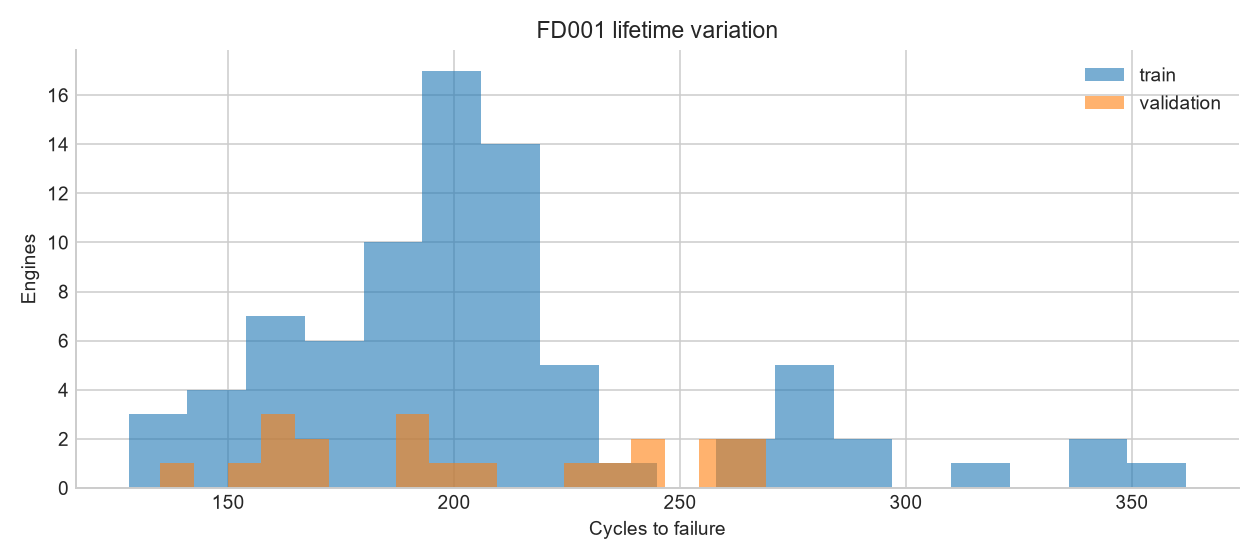

In [7]:
display(Image(filename=str(R / 'figures' / 'engine_lifetimes.png')))

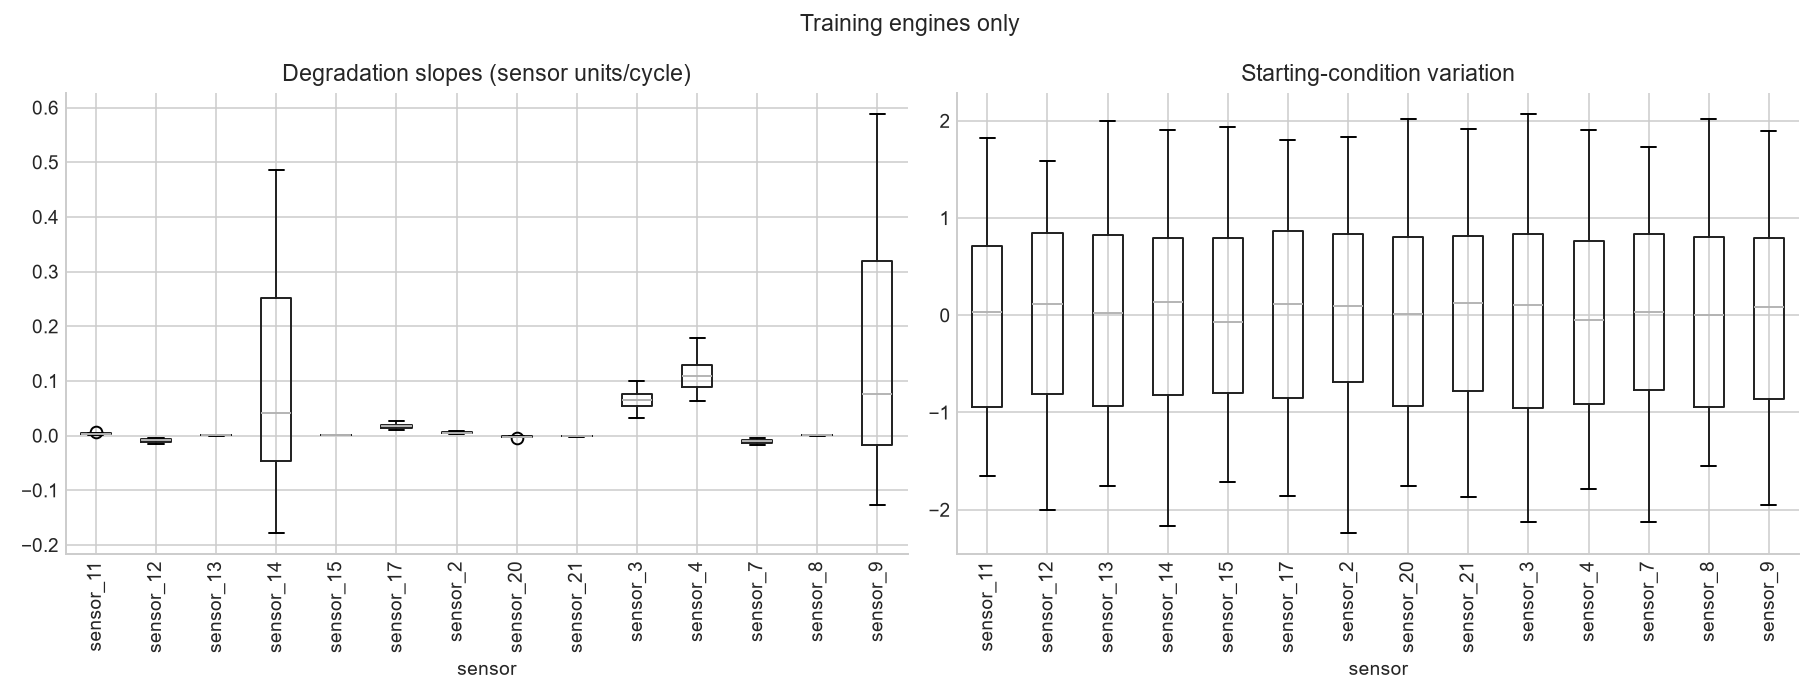

In [8]:
display(Image(filename=str(R / 'figures' / 'engine_variation.png')))

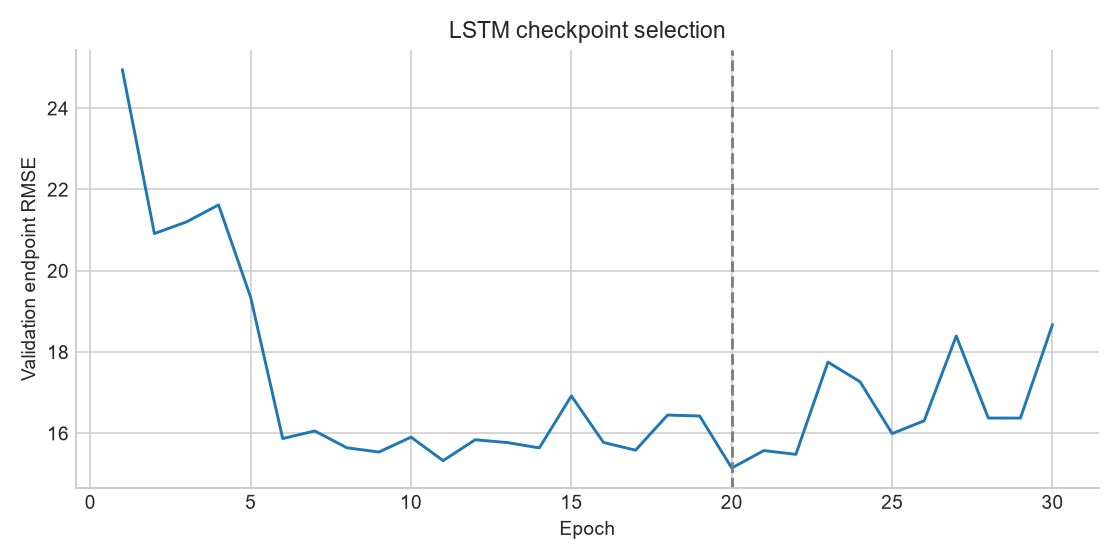

In [9]:
display(Image(filename=str(R / 'figures' / 'lstm_learning_curve.png')))

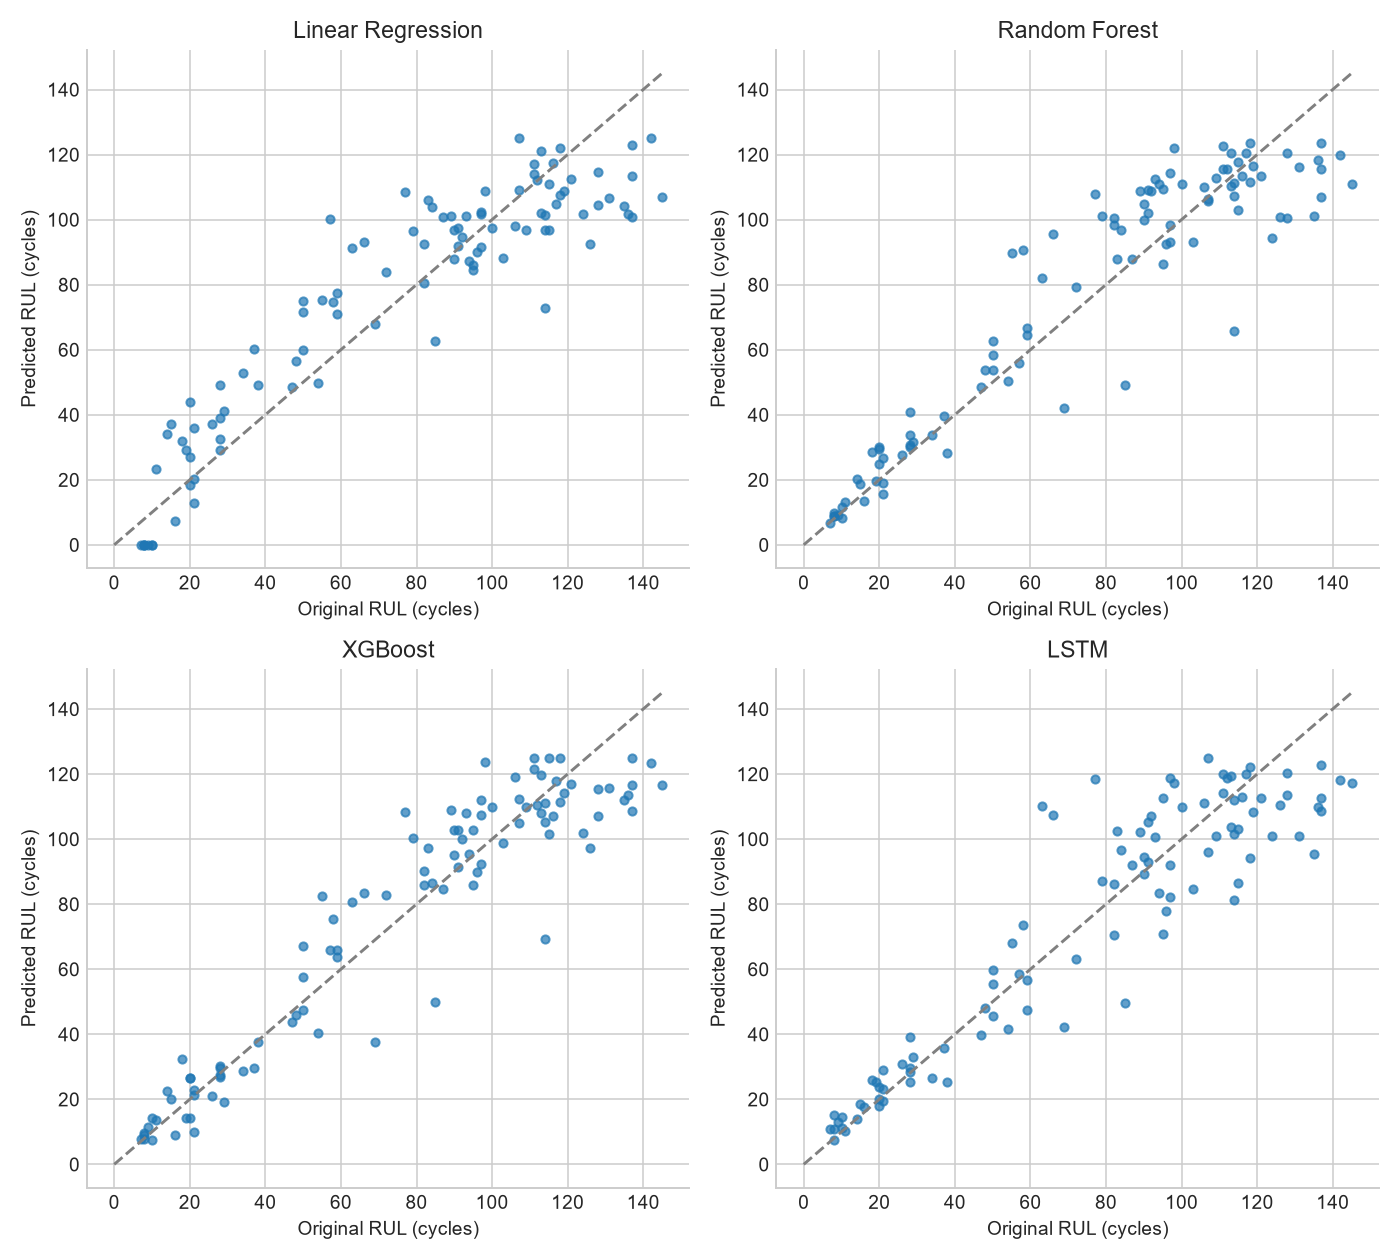

In [10]:
display(Image(filename=str(R / 'figures' / 'test_predictions.png')))

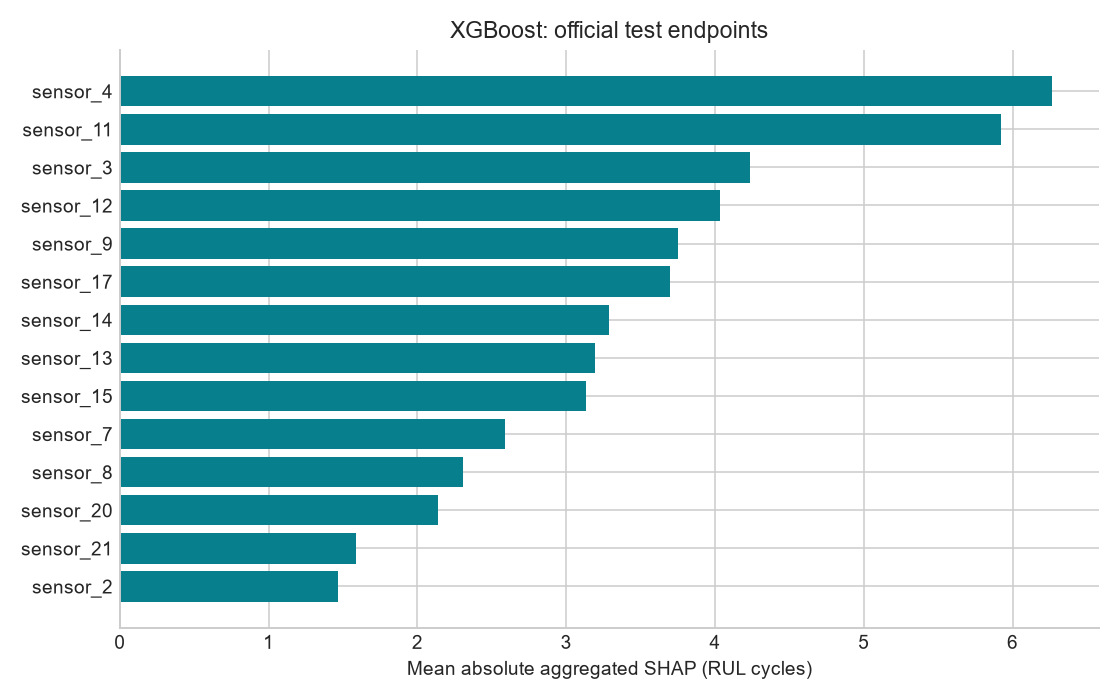

In [11]:
display(Image(filename=str(R / 'figures' / 'shap_global.png')))

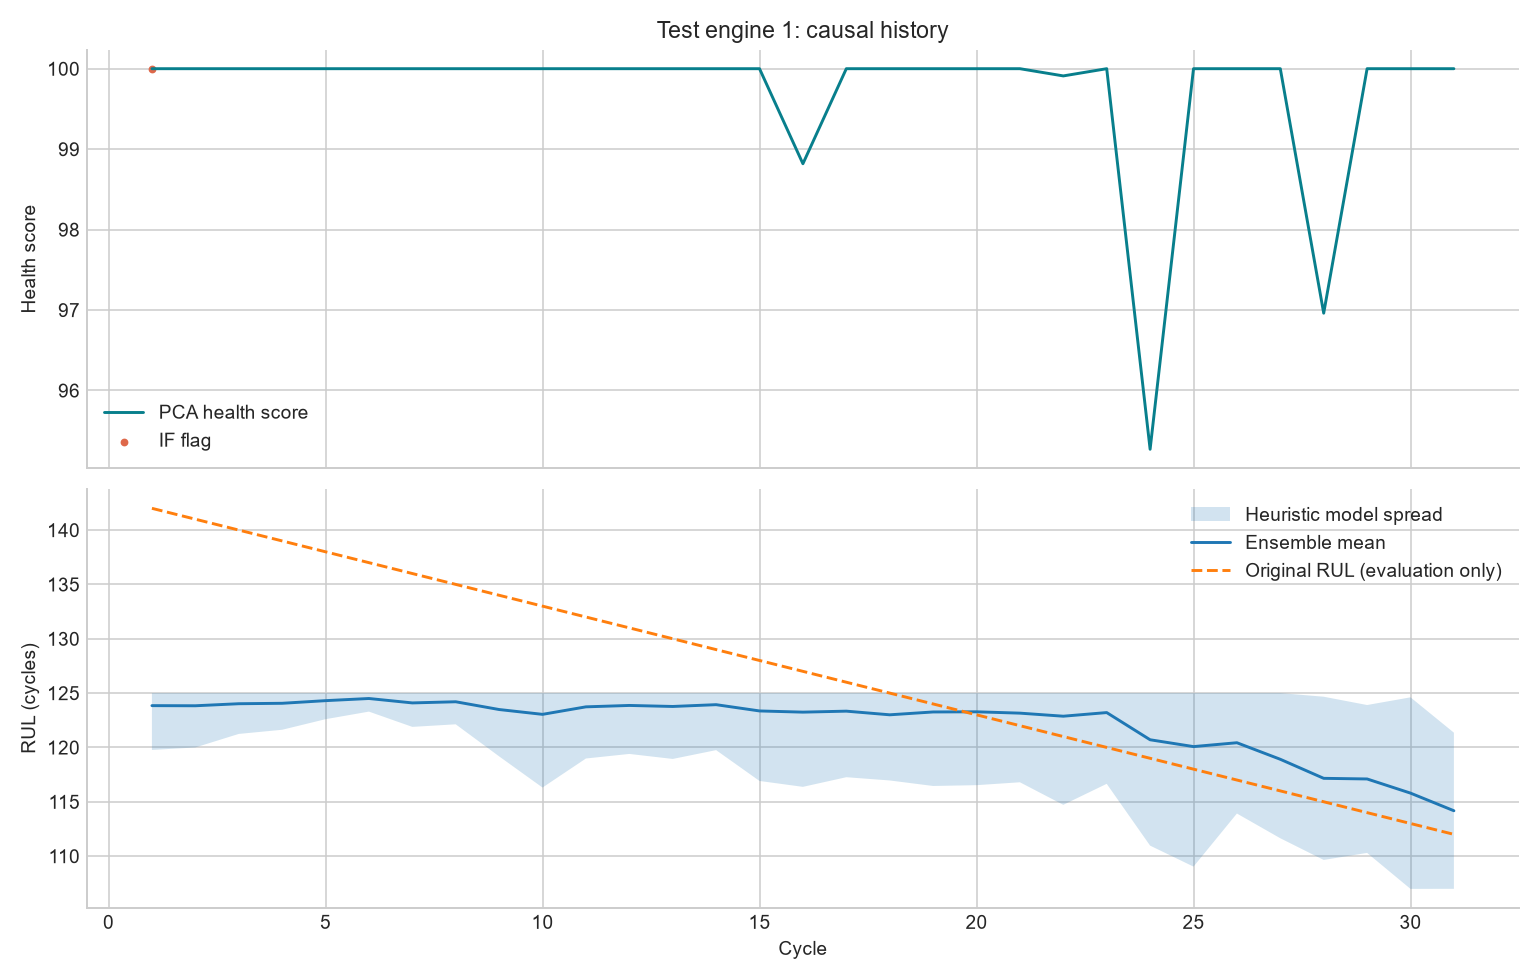

In [12]:
display(Image(filename=str(R / 'figures' / 'single_engine.png')))